In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler

In [9]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [11]:
import os

# Construct the full path to the CSV file
data_file_path = os.path.join(path, 'data.csv')

# Load the dataset
df = pd.read_csv(data_file_path)

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [12]:
print("Dataset Shape:", df.shape)

print(df.columns)

print(df.dtypes)



Dataset Shape: (569, 33)
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             flo

In [13]:
print(df.describe())

                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [14]:
print(df['diagnosis'].value_counts())

diagnosis
B    357
M    212
Name: count, dtype: int64


In [15]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [16]:

df.drop(columns=['Unnamed: 32'], inplace=True, errors='ignore')

df.drop(columns=['id'], inplace=True, errors='ignore')

print(df.head())

  diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0         M        17.99         10.38          122.80     1001.0   
1         M        20.57         17.77          132.90     1326.0   
2         M        19.69         21.25          130.00     1203.0   
3         M        11.42         20.38           77.58      386.1   
4         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   symmetry_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0         0.2419  ...         25.38          17.33 

In [17]:
print(df.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [18]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])


print("\nDuplicate Rows:", df.duplicated().sum())

Number of Rows: 569
Number of Columns: 31

Duplicate Rows: 0


In [19]:
encoder = LabelEncoder()

df['diagnosis'] = encoder.fit_transform(df['diagnosis'])

print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [20]:
print("Duplicate Rows Before:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After: 0


In [21]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert into DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print(X_scaled.head())

   radius_mean  texture_mean  perimeter_mean  area_mean  smoothness_mean  \
0     1.097064     -2.073335        1.269934   0.984375         1.568466   
1     1.829821     -0.353632        1.685955   1.908708        -0.826962   
2     1.579888      0.456187        1.566503   1.558884         0.942210   
3    -0.768909      0.253732       -0.592687  -0.764464         3.283553   
4     1.750297     -1.151816        1.776573   1.826229         0.280372   

   compactness_mean  concavity_mean  concave points_mean  symmetry_mean  \
0          3.283515        2.652874             2.532475       2.217515   
1         -0.487072       -0.023846             0.548144       0.001392   
2          1.052926        1.363478             2.037231       0.939685   
3          3.402909        1.915897             1.451707       2.867383   
4          0.539340        1.371011             1.428493      -0.009560   

   fractal_dimension_mean  ...  radius_worst  texture_worst  perimeter_worst  \
0           

## Exploratory Data Analysis (EDA)

### Histograms for Numerical Features

Let's visualize the distribution of each numerical feature using histograms. This will help us understand the spread, central tendency, and identify any skewness or outliers.

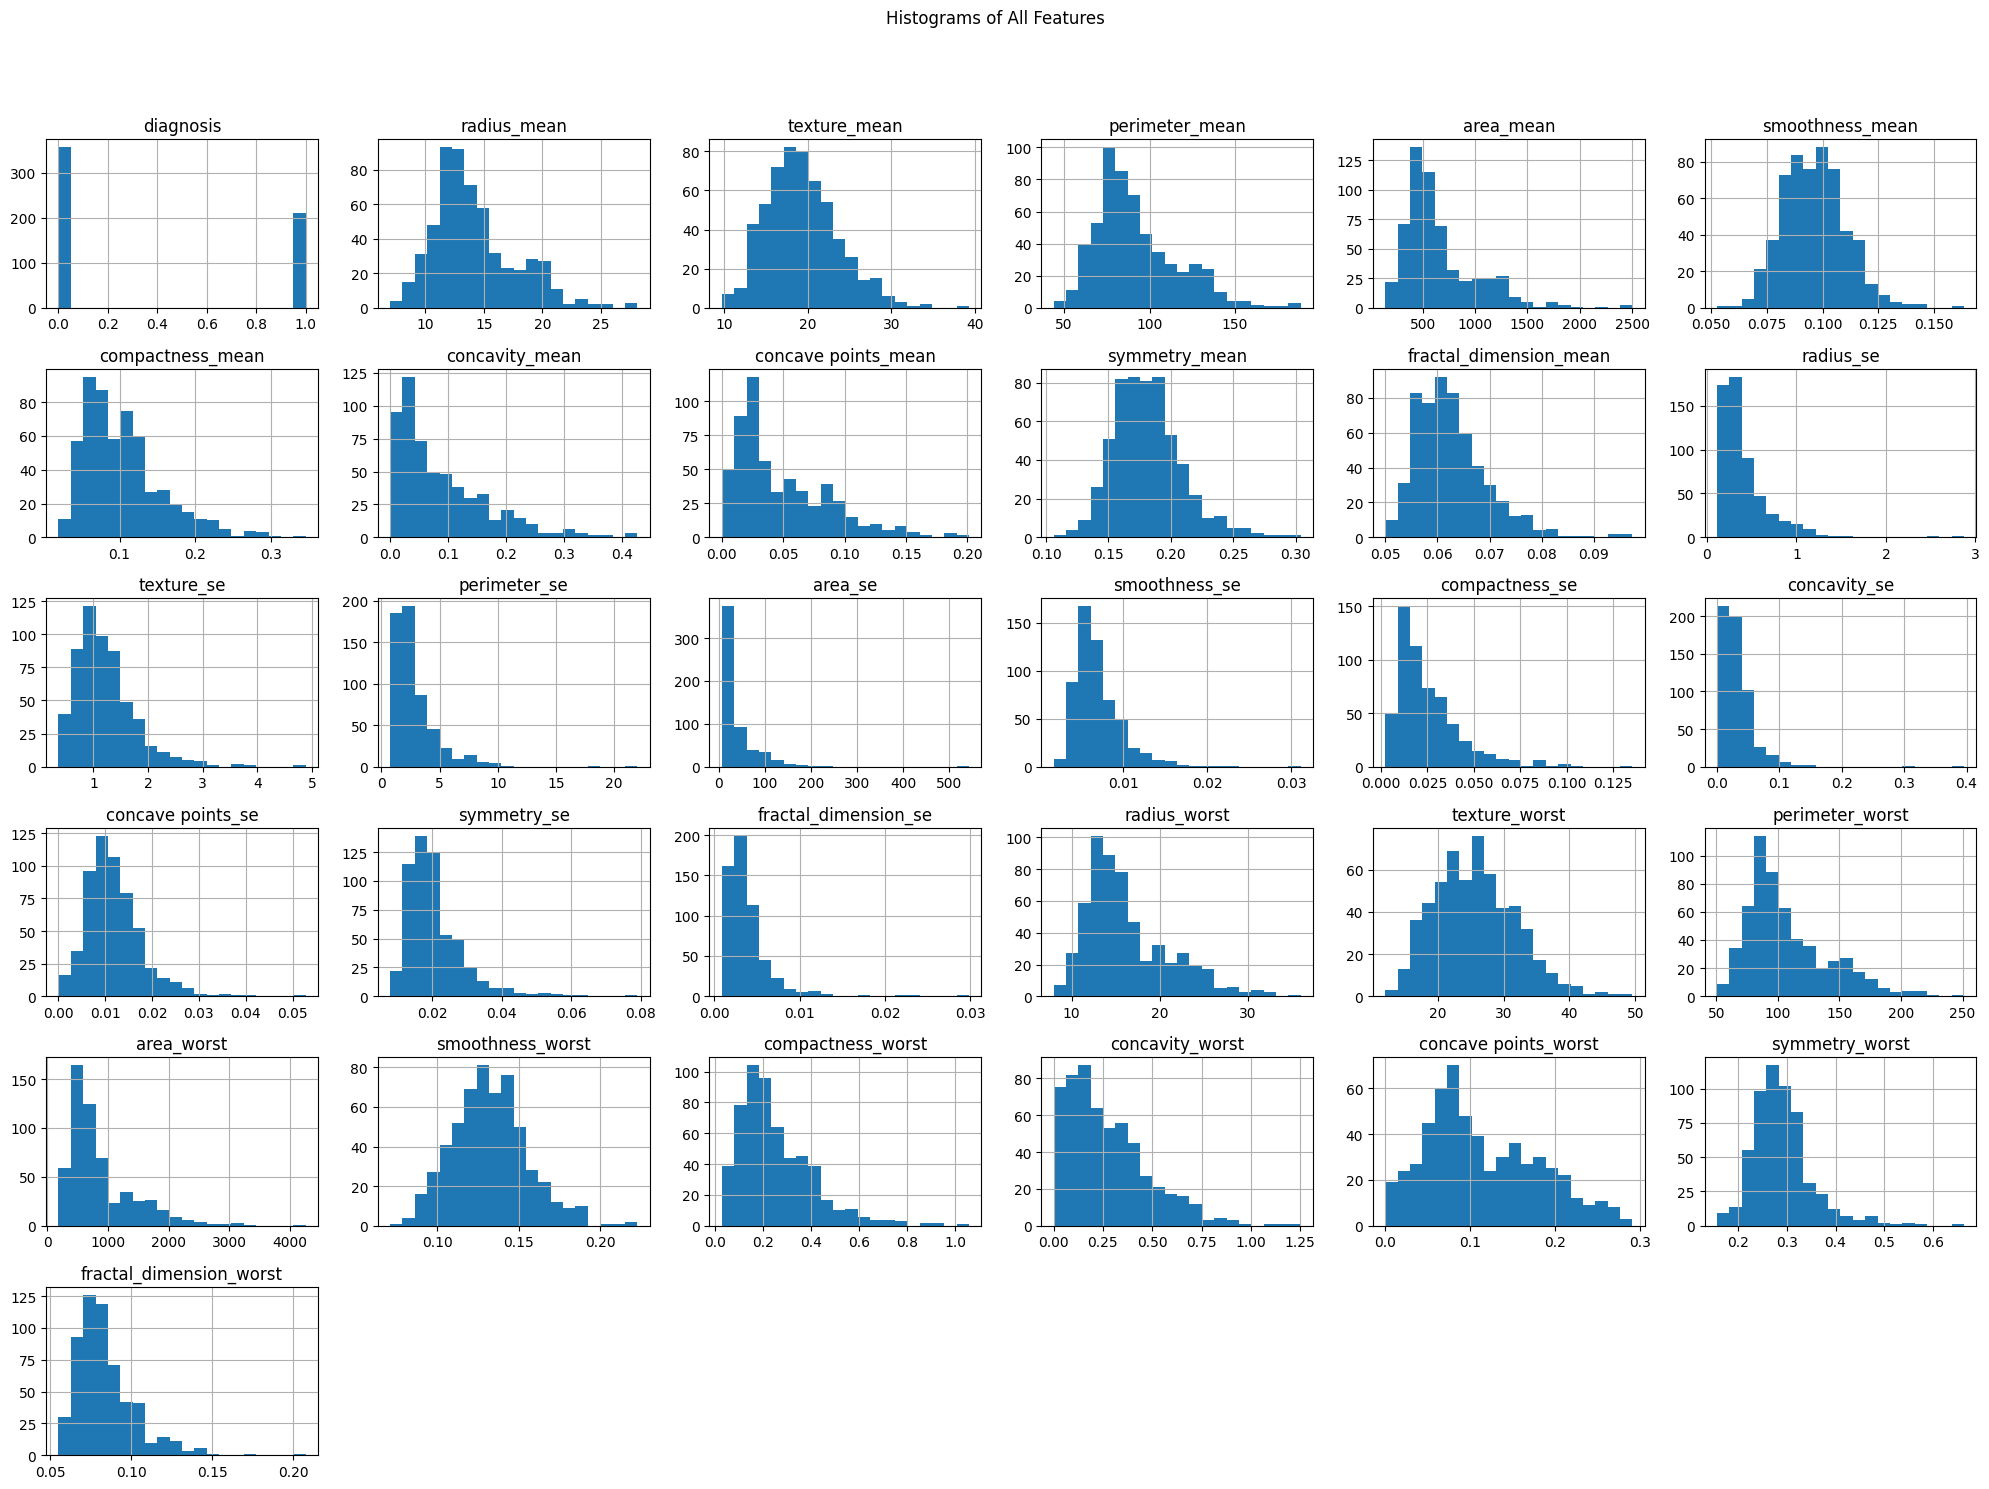

In [34]:
df.hist(bins=20, figsize=(20, 15))
plt.suptitle('Histograms of All Features', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

### Count Plot for 'diagnosis'

Now, let's look at the distribution of our target variable, 'diagnosis'.

/tmp/ipykernel_1771/56531066.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='viridis')


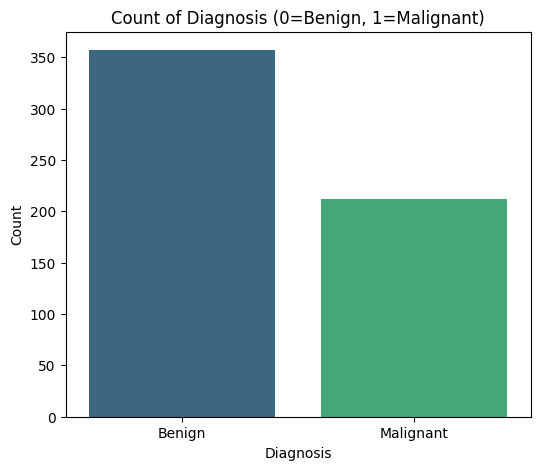

In [35]:
plt.figure(figsize=(6, 5))
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.title('Count of Diagnosis (0=Benign, 1=Malignant)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Benign', 'Malignant'])
plt.show()

### Correlation Heatmap

To understand the relationships between different features, we'll generate a correlation heatmap. This will highlight strong positive or negative correlations.

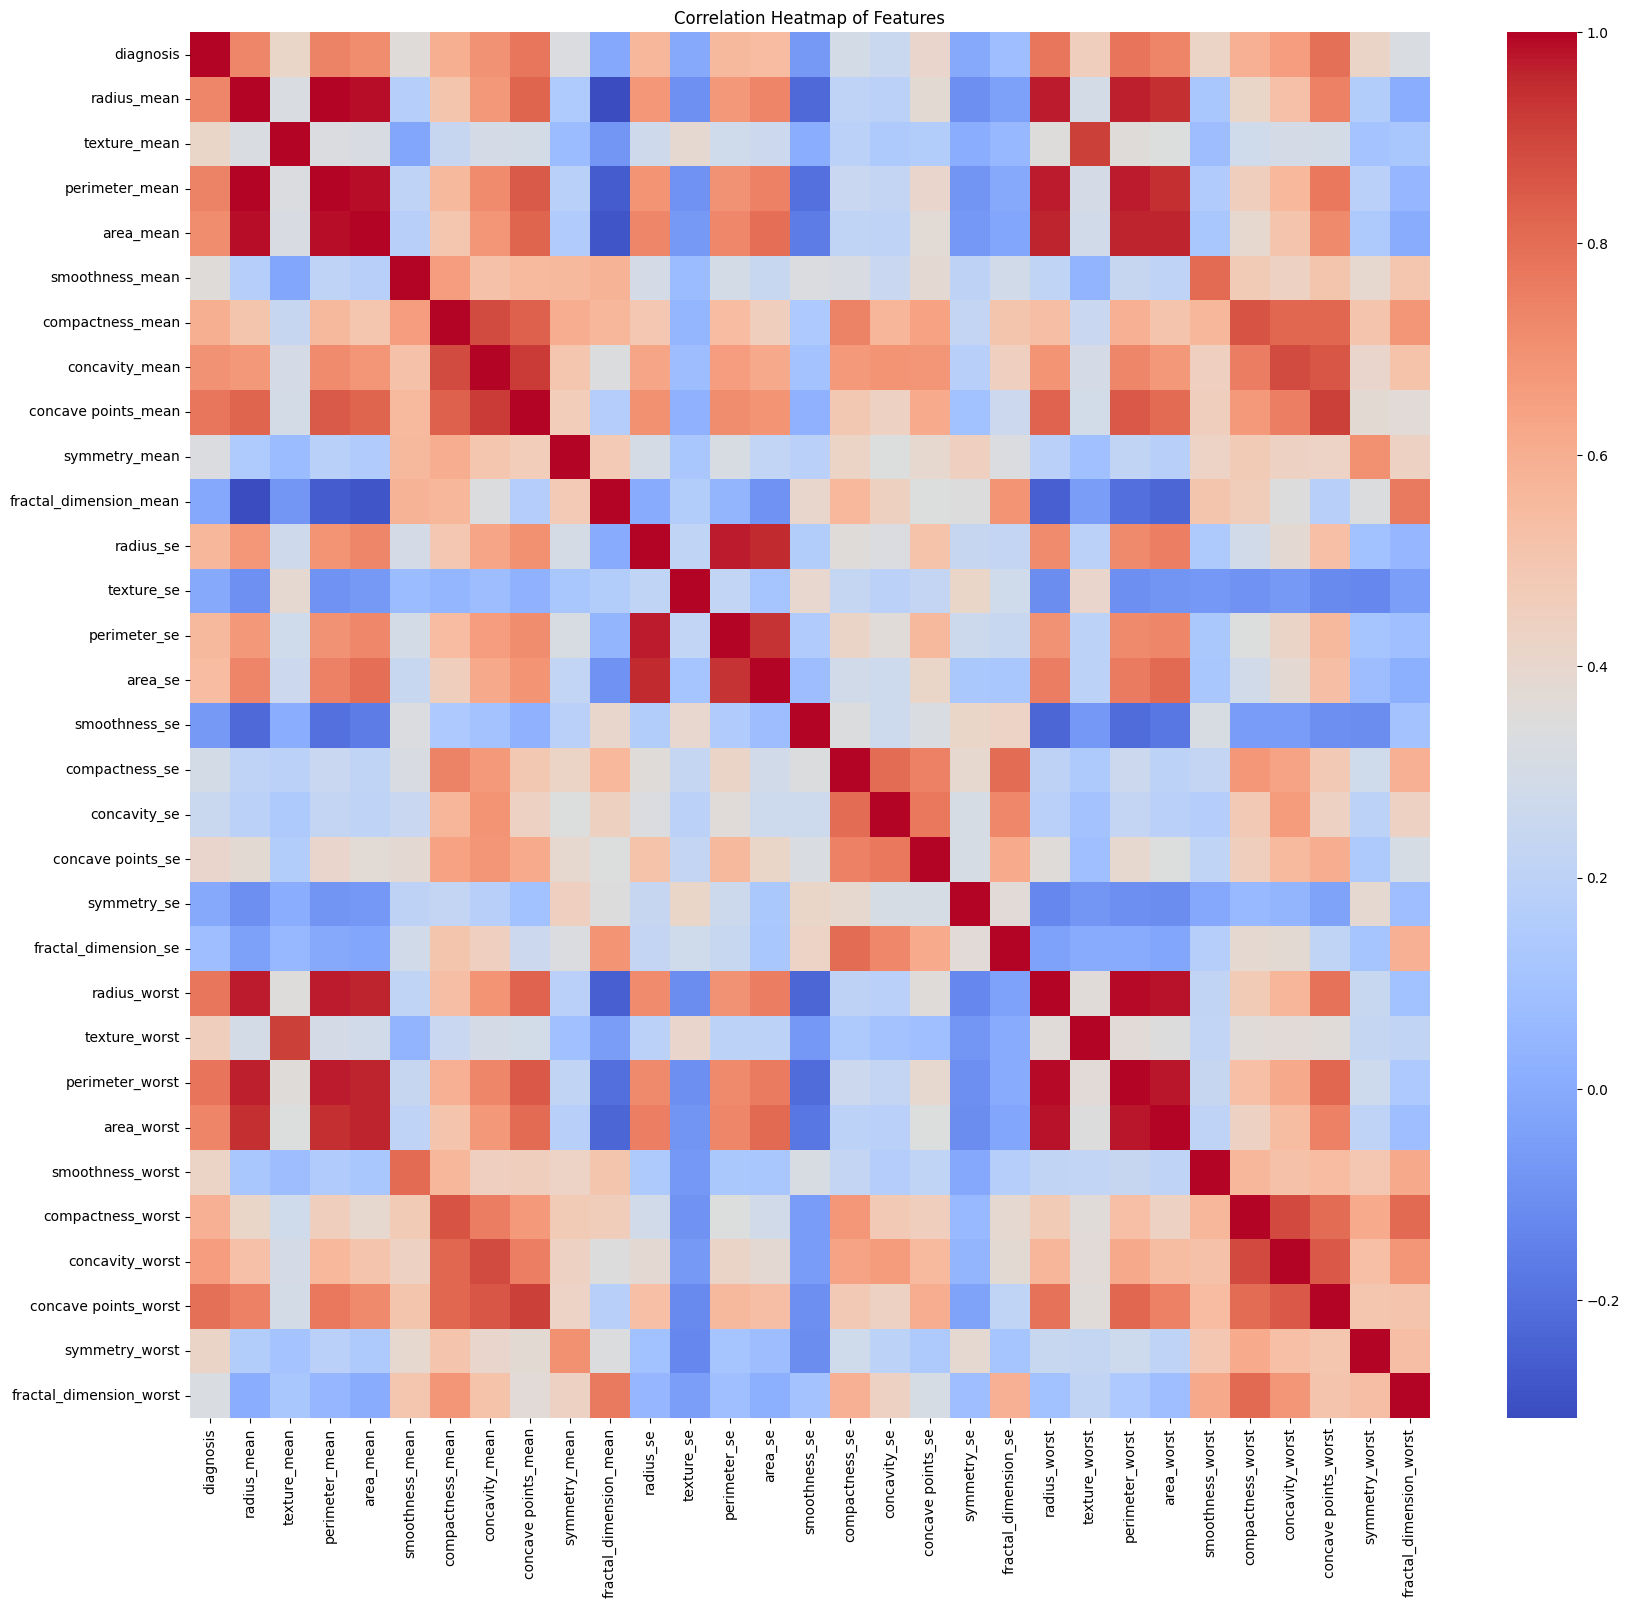

In [36]:
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Features')
plt.show()

### Boxplots for Key Features by Diagnosis

Boxplots are useful for visualizing the distribution of numerical data and comparing them across different categories (in our case, 'diagnosis'). We'll select a few representative features to demonstrate.

/tmp/ipykernel_1771/185944742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette='pastel')
/tmp/ipykernel_1771/185944742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette='pastel')
/tmp/ipykernel_1771/185944742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diagnosis', y=feature, data=df, palette='pastel')
/tmp/ipykernel_1771/185944742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

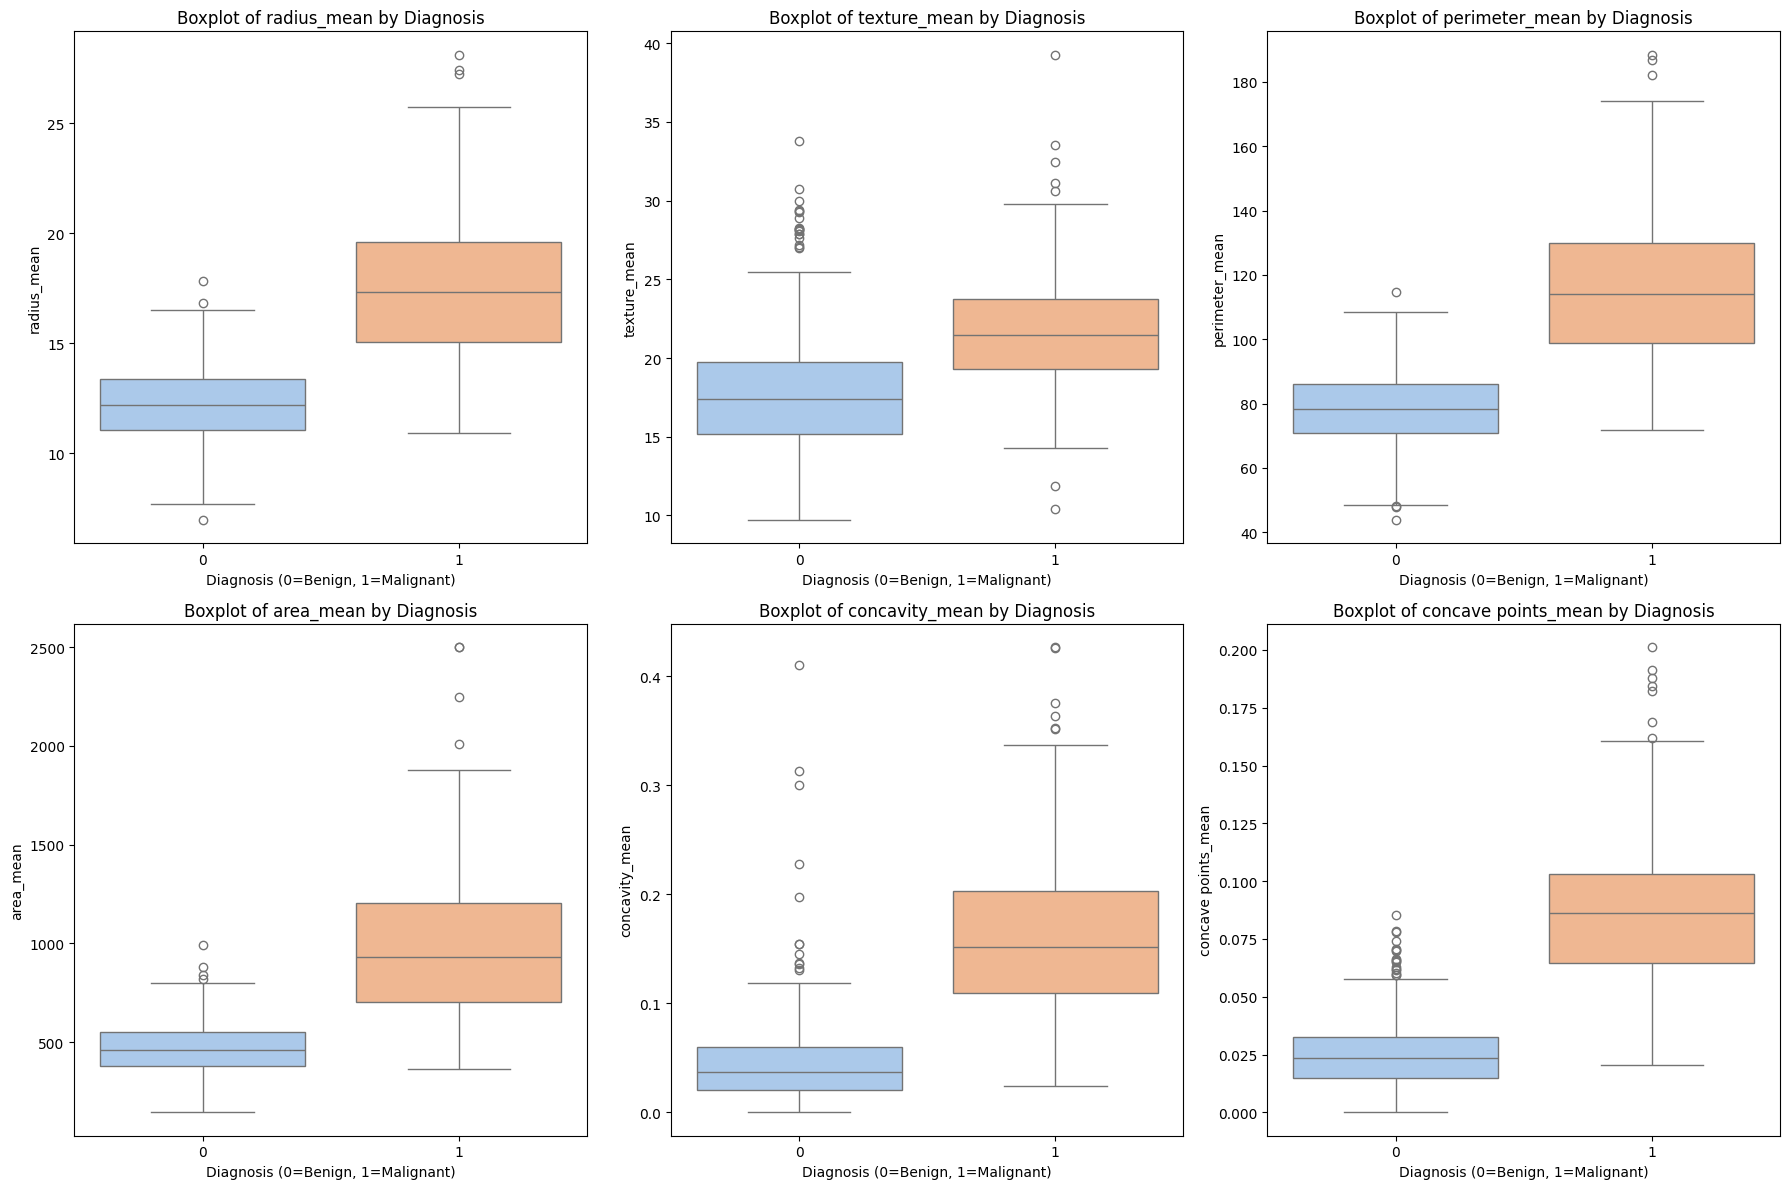

In [37]:
selected_features = [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'concavity_mean', 'concave points_mean'
]

plt.figure(figsize=(18, 12))
for i, feature in enumerate(selected_features):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.boxplot(x='diagnosis', y=feature, data=df, palette='pastel')
    plt.title(f'Boxplot of {feature} by Diagnosis')
    plt.xlabel('Diagnosis (0=Benign, 1=Malignant)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### Pairplots for Selected Features

Pairplots visualize pairwise relationships between multiple variables. Due to the high number of features, we will create a pairplot for a subset of the most relevant features to avoid an overcrowded plot.

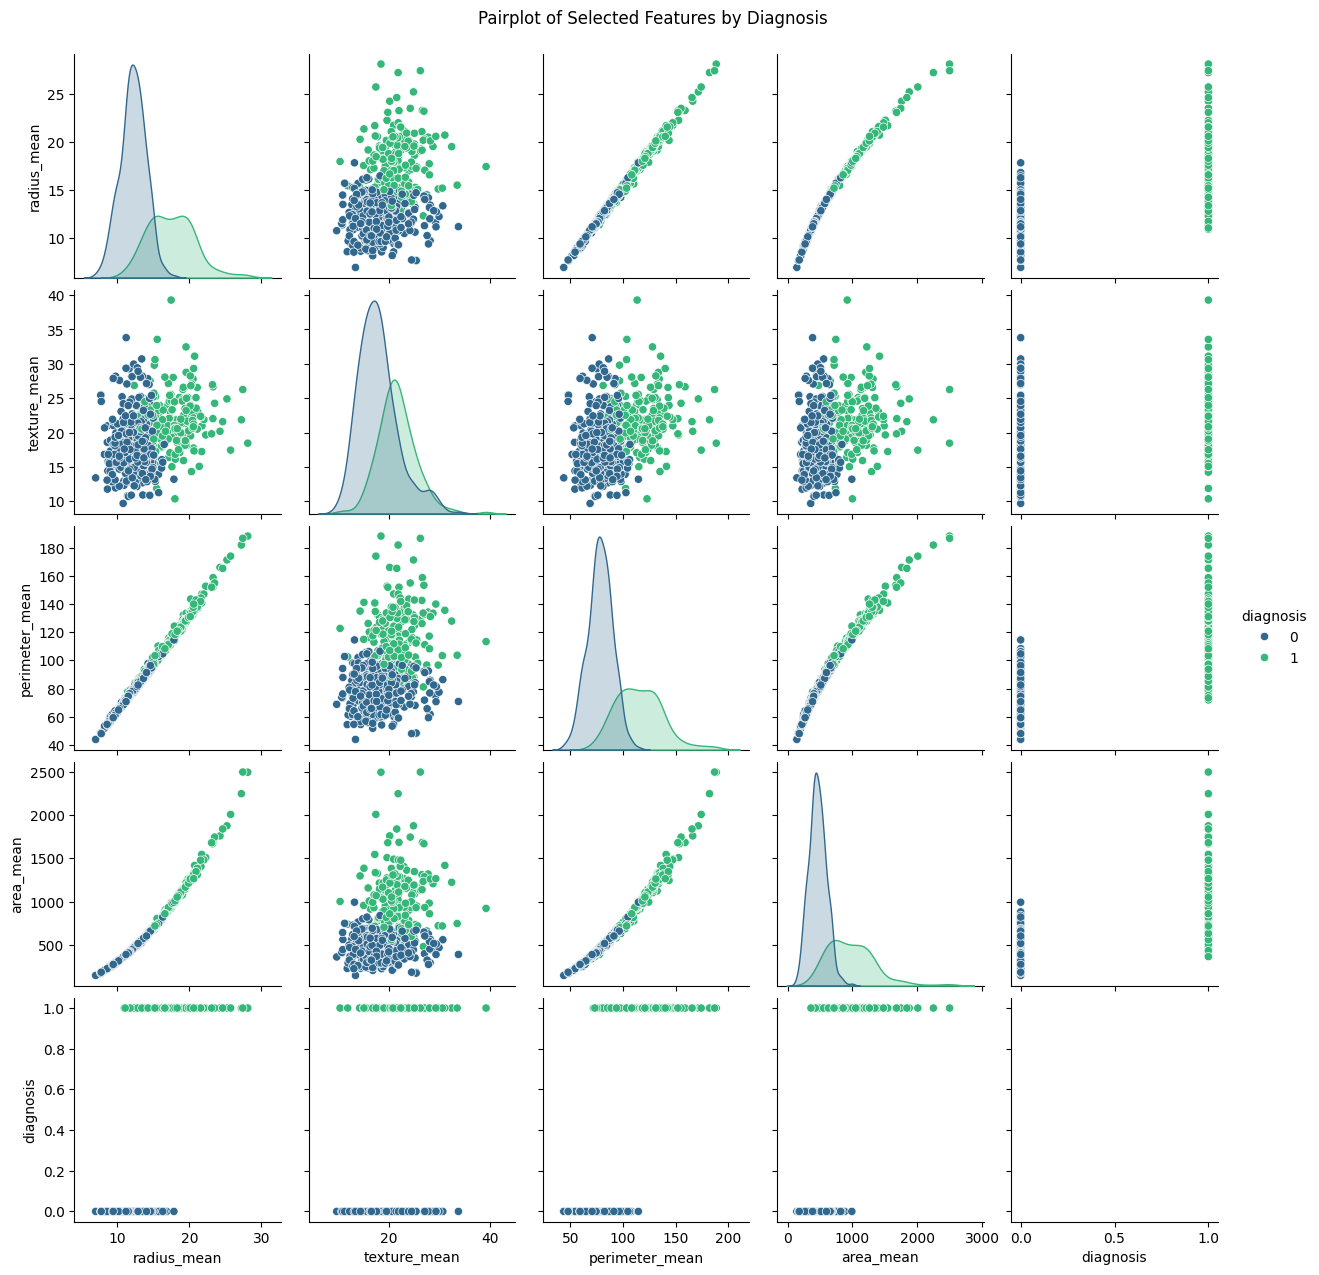

In [38]:
sns.pairplot(df, vars=['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'diagnosis'], hue='diagnosis', palette='viridis')
plt.suptitle('Pairplot of Selected Features by Diagnosis', y=1.02) # Adjust suptitle position
plt.show()

## Outlier Detection

Outliers can significantly affect model performance. We'll use boxplots to visually inspect for outliers in the scaled features. Given that the data has already been scaled, we'll examine the distributions more closely.

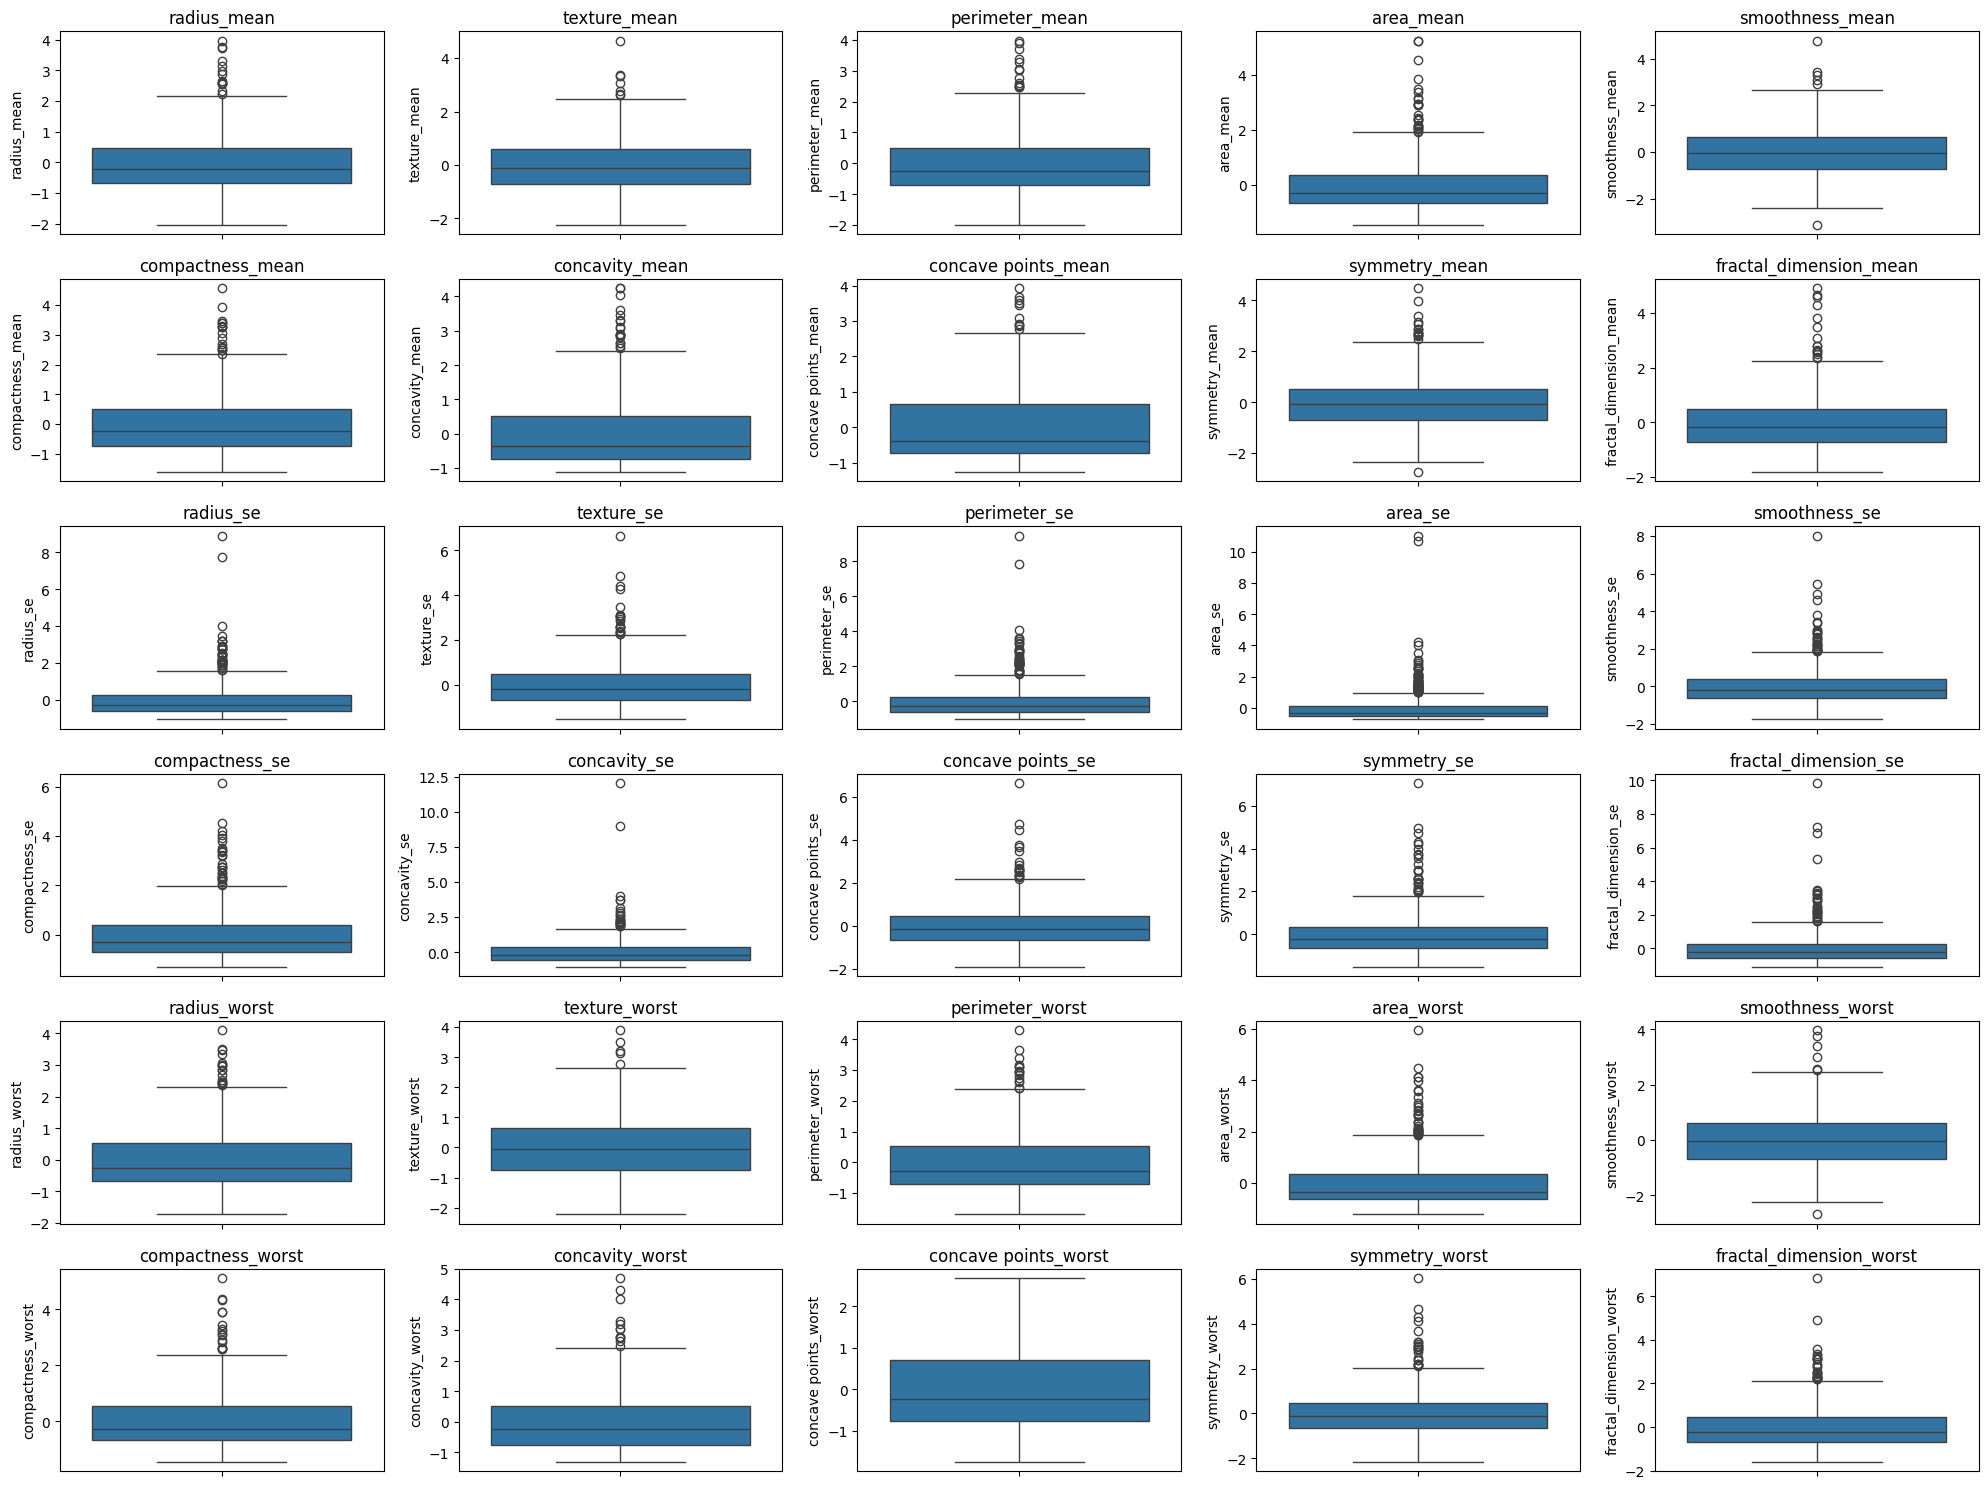

In [39]:
plt.figure(figsize=(20, 15))
for i, column in enumerate(X_scaled.columns):
    plt.subplot(6, 5, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(y=X_scaled[column])
    plt.title(column)
plt.tight_layout()
plt.show()

## Dealing with Class Imbalance using SMOTE

Our target variable ('diagnosis') shows an imbalance (357 benign vs. 212 malignant). To address this for better model training, we will use the Synthetic Minority Over-sampling Technique (SMOTE) to create synthetic samples for the minority class.

In [40]:
# Install imbalanced-learn if not already installed
!pip install imbalanced-learn

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Ensure X_train and y_train are defined right before SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Class distribution before SMOTE:\n", y_train.value_counts())
print("\nClass distribution after SMOTE:\n", y_train_resampled.value_counts())

Class distribution before SMOTE:
 diagnosis
0    286
1    169
Name: count, dtype: int64

Class distribution after SMOTE:
 diagnosis
0    286
1    286
Name: count, dtype: int64


## Correlation-based Feature Analysis and Selection

We've already seen the correlation heatmap. Now, let's identify and consider removing highly correlated features to reduce multicollinearity and improve model performance. We'll set a threshold (e.g., 0.9) to find features that are very similar.

In [41]:
# Calculate the correlation matrix for the resampled training data
corr_matrix = pd.DataFrame(X_train_resampled).corr().abs()

# Select upper triangle of correlation matrix
uppertri_corr = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation greater than a threshold (e.g., 0.9)
to_drop_high_corr = [column for column in uppertri_corr.columns if any(uppertri_corr[column] > 0.9)]

print(f"Features to consider dropping due to high correlation (>0.9): {to_drop_high_corr}")

Features to consider dropping due to high correlation (>0.9): ['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


## Model-based Feature Importance Analysis

Now, let's use a machine learning model (Random Forest) to determine the importance of each feature. This approach can capture non-linear relationships and interactions between features.

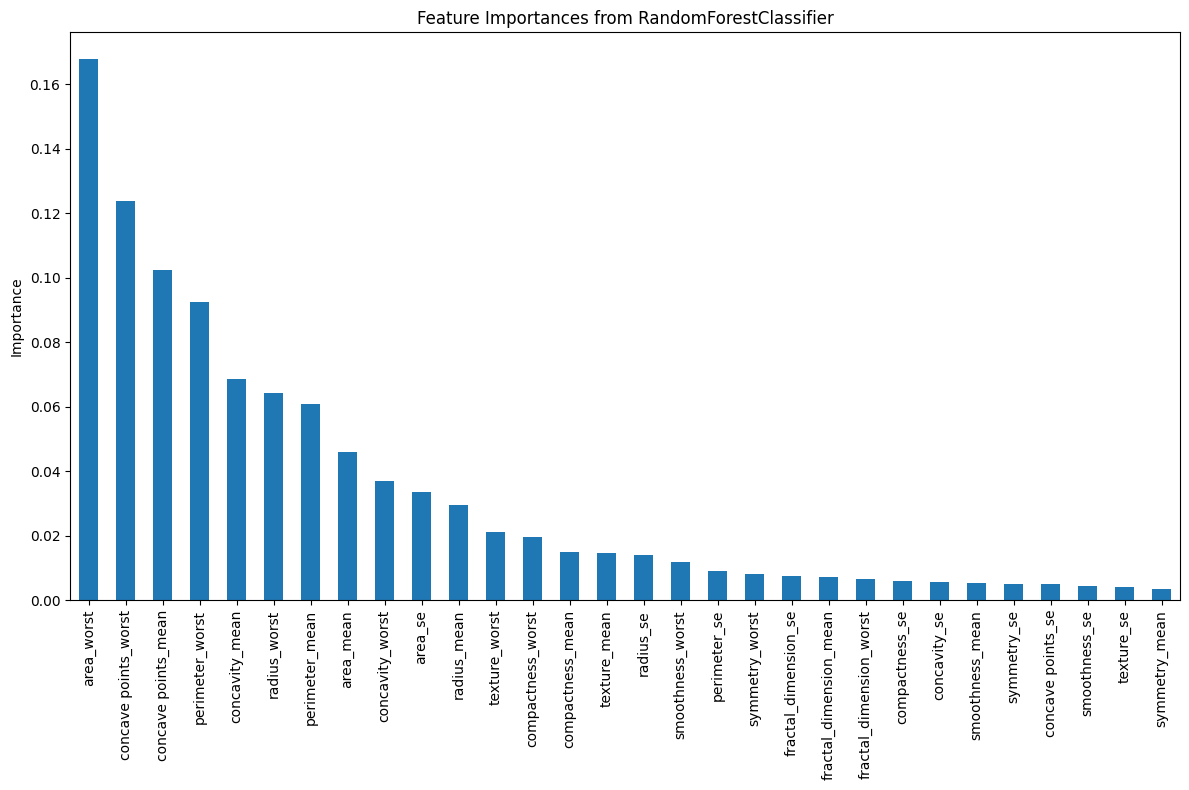

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Train a RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Get feature importances
feature_importances = pd.Series(model.feature_importances_, index=pd.DataFrame(X_train_resampled).columns)

# Sort feature importances and plot them
plt.figure(figsize=(12, 8))
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importances from RandomForestClassifier')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()